# Projet VERNAY

## Importation des données

In [265]:
#On fixe l'aléatoire pour la reproducibilité des résultats
import random
import numpy as np
import tensorflow as tf

SEED = 23
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [266]:
# A partir du package tensorflow, on importe le dataset labeled faces in the wild
import tensorflow_datasets as tfds

data, info = tfds.load('lfw', shuffle_files=True, with_info=True)

## Exploration des données

In [267]:
#On a la possibilité d'afficher des informations sur le dataset
print(info)

tfds.core.DatasetInfo(
    name='lfw',
    full_name='lfw/0.1.1',
    description="""
    Labeled Faces in the Wild: A Database for Studying Face Recognition in
    Unconstrained Environments
    """,
    homepage='http://vis-www.cs.umass.edu/lfw',
    data_dir='/Users/matt/tensorflow_datasets/lfw/0.1.1',
    file_format=tfrecord,
    download_size=172.20 MiB,
    dataset_size=180.28 MiB,
    features=FeaturesDict({
        'image': Image(shape=(250, 250, 3), dtype=uint8),
        'label': Text(shape=(), dtype=string),
    }),
    supervised_keys=('label', 'image'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=13233, num_shards=2>,
    },
    citation="""@TechReport{LFWTech,
        author = {Gary B. Huang and Manu Ramesh and Tamara Berg and Erik Learned-Miller},
        title = {Labeled Faces in the Wild: A Database for Studying Face Recognition in Unconstrained Environments},
        institution = {University of 

On voit qu'on a des images de 250 par 250 par 3 (donc 250*250 en couleur). On a aussi un label correspondant.

In [268]:
# On veut inspecter un peu l'objet retourné
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['train'])


On observe qu'on obtient un dictionnaire avec des données d'entraînement.

In [269]:
#Maintenant, inspectons plus en détail ce que contient l'objet

for ensemble in data['train'].take(1):
  print(type(ensemble))
  print(ensemble.keys())
  print("Image shape : ",ensemble['image'].shape)
  print("Label :", ensemble['label'])

<class 'dict'>
dict_keys(['image', 'label'])
Image shape :  (250, 250, 3)
Label : tf.Tensor(b'John_Abizaid', shape=(), dtype=string)


2026-04-03 21:06:42.314952: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


On a donc des dictionnaires dans un dictionnaire. Chacun de ces dictionnaires contient l'image ainsi qu'un label correspondant. Le label est de type Tensor.

In [270]:
# Pour extraire la valeur d'un tensor, on utilise la méthode .numpy()
for ensemble in data['train'].take(1):
  print("Label (Tensor) : ", ensemble['label'])
  print("Label (Chaîne) : ", ensemble['label'].numpy())

Label (Tensor) :  tf.Tensor(b'Tom_Amstutz', shape=(), dtype=string)
Label (Chaîne) :  b'Tom_Amstutz'


2026-04-03 21:06:42.462371: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-04-03 21:06:42.634618: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


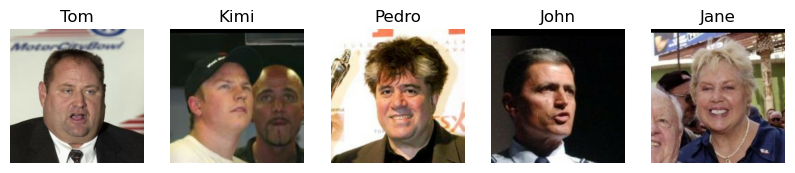

In [271]:
#On regarde un peu à quoi ressemble les images
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i, exemple in enumerate(data['train'].take(5)):
    plt.subplot(1, 5, i+1)
    plt.imshow(exemple['image'].numpy())
    plt.title(exemple['label'].numpy().decode('utf-8').split('_')[0])
    plt.axis('off')
plt.show()

## Préparation des données

Dans l'objectif d'entraîner FaceNet, on doit construire des triplets (anchor, positive, negative). Pour ça on veut d'abord regrouper les données par personnes dans un dictionnaire du type :

{"personne1": [image1, image2, ...],
 "peronne 2": ['image1, image2, ...],
  ...}

In [272]:
# On itère sur data["train"] pour rassembler les images d'une même personne dans sa clé de dictionnaire :

data_pers = {}

for personne in data['train']:

  #Si la personne n'est pas encore dans le dictionnaire, on l'ajoute
  if personne['label'].numpy() not in data_pers:
    data_pers[personne['label'].numpy()] = []

  #On ajoute l'image à la personne correspondante
  data_pers[personne['label'].numpy()].append(personne['image'])


2026-04-03 21:06:47.681252: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [273]:
#On visualise notre résultat (juste le début)
{k: data_pers[k] for k in list(data_pers)[:2]}



{b'Tom_Amstutz': [<tf.Tensor: shape=(250, 250, 3), dtype=uint8, numpy=
  array([[[207, 209, 195],
          [207, 209, 195],
          [208, 210, 196],
          ...,
          [215, 218, 201],
          [215, 218, 201],
          [215, 218, 201]],
  
         [[207, 209, 195],
          [207, 209, 195],
          [208, 210, 196],
          ...,
          [215, 218, 201],
          [215, 218, 201],
          [215, 218, 201]],
  
         [[207, 209, 195],
          [207, 209, 195],
          [208, 210, 196],
          ...,
          [215, 218, 201],
          [215, 218, 201],
          [215, 218, 201]],
  
         ...,
  
         [[ 30,  29,  25],
          [ 29,  28,  24],
          [ 29,  28,  24],
          ...,
          [ 24,  22,  23],
          [ 23,  21,  22],
          [ 23,  21,  22]],
  
         [[ 30,  29,  25],
          [ 29,  28,  24],
          [ 29,  28,  24],
          ...,
          [ 27,  25,  26],
          [ 25,  23,  24],
          [ 24,  22,  23]],
  
       

In [274]:
# Les personnes qui n'ont qu'une image ne sont pas exploitables, la prochaine étape est de les enlever

print("Nombre de personnes au total : ", len(data_pers))

i = len([k for k in data_pers if len(data_pers[k]) >= 2])

print("On a", i, "personnes avec au moins 2 images")

#On ne garde que les personnes avec au moins deux images à l'aide de cette compréhension de liste
data_pers_filtered = {k: data_pers[k] for k in data_pers.keys() if len(data_pers[k])>=2}

#On montre
{k: data_pers_filtered[k] for k in list(data_pers_filtered)[:2]}

Nombre de personnes au total :  5749
On a 1680 personnes avec au moins 2 images


{b'Kimi_Raikkonen': [<tf.Tensor: shape=(250, 250, 3), dtype=uint8, numpy=
  array([[[  0,   0,   0],
          [  0,   0,   0],
          [  0,   0,   0],
          ...,
          [  0,   0,   0],
          [  0,   0,   0],
          [  0,   0,   0]],
  
         [[  0,   0,   0],
          [  0,   0,   0],
          [  0,   0,   0],
          ...,
          [  0,   0,   0],
          [  0,   0,   0],
          [  0,   0,   0]],
  
         [[  1,   1,   1],
          [  1,   1,   1],
          [  1,   1,   1],
          ...,
          [  0,   0,   0],
          [  0,   0,   0],
          [  0,   0,   0]],
  
         ...,
  
         [[220, 215, 196],
          [221, 216, 197],
          [222, 216, 200],
          ...,
          [ 34,  39,  32],
          [ 33,  38,  31],
          [ 33,  38,  31]],
  
         [[220, 214, 198],
          [222, 216, 200],
          [223, 217, 201],
          ...,
          [ 33,  38,  31],
          [ 33,  38,  31],
          [ 33,  38,  31]],
  
    

In [275]:
#A partir de là, on a besoin d'une fonction qui nous renvoie une liste de triplets de cette forme : (cible, positif, négatif) ;
#où la cible est l'image d'une personne, positif une image différente de la même personne, et négatif est l'image d'une personne différente

def create_triplets(data_pers_filtered):

  #On initie la liste qui contiendra les triplets
  liste_trip = []

  #On boucle sur chaque personne et ses valeurs
  for pers, im in data_pers_filtered.items():

    #On prend deux images de la personne au hasard sans remise ET
    #On normalise les images : pour l'instant les pixels prennent des valeurs entre 0 et 255, mais par convention on veut normaliser entre 0 et 1
    #On redimensionne les images car sinon elles sont trop grandes et le temps ainsi que la puissance computationnelle sont trop élevés
    cible, pos = [tf.image.resize(image, (128, 128)) / 255.0 for image in tf.cast(random.sample(im, 2), tf.float32)]
    

    #On prend une autre image au hasard en enlevant la personne cible
    autres = [p for p in data_pers_filtered if p != pers]
    neg_pers = random.choice(autres)

    #On normalise aussi
    neg = tf.cast(random.choice(data_pers_filtered[neg_pers]), tf.float32) / 255.0
    neg = tf.image.resize(neg, (128, 128)) / 255.0

    #On ajoute le triplet à la liste
    liste_trip.append((cible, pos, neg))

  #On retourne notre résultat
  return liste_trip

data_norm = create_triplets(data_pers_filtered)

#On visualise le premier triplet
data_norm[0]



(<tf.Tensor: shape=(128, 128, 3), dtype=float32, numpy=
 array([[[0.3723652 , 0.3998162 , 0.36844364],
         [0.3916054 , 0.42297795, 0.37984067],
         [0.39734533, 0.42871788, 0.38004437],
         ...,
         [0.57346815, 0.63621324, 0.5303309 ],
         [0.5887868 , 0.6515319 , 0.5456495 ],
         [0.608027  , 0.6707721 , 0.5648897 ]],
 
        [[0.3723652 , 0.3998162 , 0.36844364],
         [0.38992035, 0.41833234, 0.38407677],
         [0.39439338, 0.42576593, 0.38091633],
         ...,
         [0.5728231 , 0.6355682 , 0.5296858 ],
         [0.5887868 , 0.6515319 , 0.5456495 ],
         [0.608027  , 0.6707721 , 0.5648897 ]],
 
        [[0.36428773, 0.3917387 , 0.36428773],
         [0.37907475, 0.40652573, 0.37803477],
         [0.3843063 , 0.4147523 , 0.37439469],
         ...,
         [0.5710404 , 0.6337855 , 0.52790314],
         [0.5887868 , 0.6515319 , 0.5456495 ],
         [0.608027  , 0.6707721 , 0.5648897 ]],
 
        ...,
 
        [[0.8560746 , 0.89529026

## Implémentation du premier modèle : Facenet

Facenet est un modèle qui produit des embeddings à partir d'une image. Un embedding est une représentation en 1D de l'image, qui est ensuite utilisée pour comparer différentes images. L'objectif est, si deux embeddings sont similaires, de prédire que ce sont les mêmes visages.
Dans ce réseau de neurone, on extrait les features d'un visage, ce qui permet ensuite de faire l'embedding.



In [276]:
# On crée une fonction qui retourne un modèle FaceNet

def create_model():

  #Le sequential permet d'enchaîner plusieurs traitement à la suite ; c'est un Pipeline
    model = tf.keras.Sequential([

        #Avant tout, on définit la dimension des images en entrée
        tf.keras.Input(shape=(128, 128, 3)),

        #Conv2D correspond à la couche du réseau de neurone. Par exemple ici on met 32 noeuds pour la première couche.
        # Avec MaxPooling2D, ils permettent d'extraire les features du visage de l'image
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        # On ajoute quelques blocs pour avoir un réseau complexe, en augmentant le nombre de neurones par couche
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        #On met en 1D
        tf.keras.layers.Flatten(),

        #On produit l'embedding de taille 128
        tf.keras.layers.Dense(128)
    ])
    return model

Quelques éléments sur les couches Conv2D et MaxPooling2D.

**Conv2D** est une fonction qui permet d'extraire les features d'un visage : par exemple pour le premier Conv2D, ce sont 32 features qui sont extraits (1er argument de la fonction). Ces features correspondent en fait à des "sous images" de 3 pixels par 3 pixels (3*3 : le 2e argument de la fonction).

**MaxPooling2D** permet de réduire la complexité et la taille de notre résultat, afin de résister aux légères variations.

In [277]:
#On extrait donc notre modèle, puis on visualise un peu ses caractéristiques

embedding_model_face = create_model()
embedding_model_face.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_140 (Conv2D)             │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_85 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_141 (Conv2D)             │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_86 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_142 (Conv2D)             │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_87 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │     3,211,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,640 (12.61 MB)

 Trainable params: 3,304,640 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

On retrouve bien les différentes couches qu'on a définit.

Maintenant, on arrive dans le coeur de FaceNet, avec sa formule :

L = max(0, distance(cible, pos)-distance(cible, neg) + alpha)

avec L le paramètre loss et
 alpha un paramètre d'erreur

In [278]:
#On veut une fonction qui nous donne la valeur de loss pour un triplet :

def triplet_loss(cible, positive, negative, alpha=0.2):
    # On calcul les distances (norme L2 au carré) ; la fonction reduce_sum permet simplement de faire l'addition deux par deux des éléments de tensor
    d_pos = tf.reduce_sum(tf.square(cible - positive), axis=-1)
    d_neg = tf.reduce_sum(tf.square(cible - negative), axis=-1)

    # la fonciton tf.maximum retourne le maximum issu de la comparaison deux par deux des éléments de deux tensor
    loss = tf.maximum(0.0, d_pos - d_neg + alpha)

    # Pour finir, on fait la moyenne sur ces maximum
    return tf.reduce_mean(loss)

In [279]:
# Maintenant qu'on a tout ces éléments, on définir une boucle d'entraînement, qui utilise la fonction de calcul de la loss pour mettre à jour ses poids

#L'optimizer adam permet d'optimiser les poids de notre réseau de neurones en se basant sur la méthode de descente de gradient
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

def train_step(cible, positive, negative, model):

  #On utilise with pour enregistrer les poids dans Gradient
    with tf.GradientTape() as tape:
        # On passe les 3 images dans le modèle qu'on a définit plus pour obtenir les embeddings
        emb_cible    = model(cible)
        emb_positive = model(positive)
        emb_negative = model(negative)

        # Calcule la loss
        loss = triplet_loss(emb_cible, emb_positive, emb_negative)

    # On calcul les gradients et on met à jour les poids
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

In [280]:
#On définit la boucle d'entraînement
import matplotlib.pyplot as plt

#Les epochs représentent le nombre de passage complet fait sur les données
def train(triplets, model, epochs=5):


  tot_losses = []

  for epoch in range(epochs):

    total_loss = 0

    for (cible, pos, neg) in triplets:
      # Les images doivent avoir une dimension batch : (1, 128, 128, 3)
      cible    = tf.expand_dims(cible, axis=0)
      pos = tf.expand_dims(pos, axis=0)
      neg = tf.expand_dims(neg, axis=0)

      loss = train_step(cible, pos, neg, model)

      total_loss += loss

    print(f"Epoch {epoch+1}, Loss moyenne: {total_loss / len(triplets):.4f}")
    tot_losses.append(total_loss)

  #On fait un graphique pour illustrer l'évolution du paramètre en fonction du nombre d'epochs (tour complet sur les données)
  plt.figure(figsize=(10, 5))
  plt.plot(range(epochs), tot_losses, marker = 'o', color='blue')
  plt.title("Evolution de la valeur de fonction\nau fur et à mesure des epochs")
  plt.xlabel("Nombre d'epochs effectué")
  plt.ylabel("Valeur de loss")


Plus loin dans le notebook, on entraînera le modèle sur nos données d'entraînement.

## Evaluation de FaceNet

In [281]:
from sklearn.model_selection import train_test_split

#On prépare un ensemble de données avec 500 personnes, pour avoir 400 personnes dans le train avec un test_size=0.2
keys = random.sample(list(data_pers_filtered), 1200)
values = [data_pers_filtered[k] for k in keys]


#On sépare en données d'entraînement et données de test
X_train, X_test, y_train, y_test = train_test_split(values, keys, test_size=0.2, random_state=1)

#Pour les données train, le traitement redimension en normalisation arrive après ; mais pour test on doit le faire manuellement
#après le résultat médiocre on enlève un peu ce redimensionnage
X_test = [tf.image.resize(im, (128, 128)) / 255.0 for im in X_test]

#On remet sous forme de dictionnaire 
data_train = dict(zip(y_train, X_train))
data_test = dict(zip(y_test, X_test))


In [282]:
print("Personnes en train:", len(data_train))
print("Personnes en test:", len(data_test))

Personnes en train: 960
Personnes en test: 240


Epoch 1, Loss moyenne: 5.7637
Epoch 2, Loss moyenne: 0.0000
Epoch 3, Loss moyenne: 0.0000
Epoch 4, Loss moyenne: 0.0000
Epoch 5, Loss moyenne: 0.0000


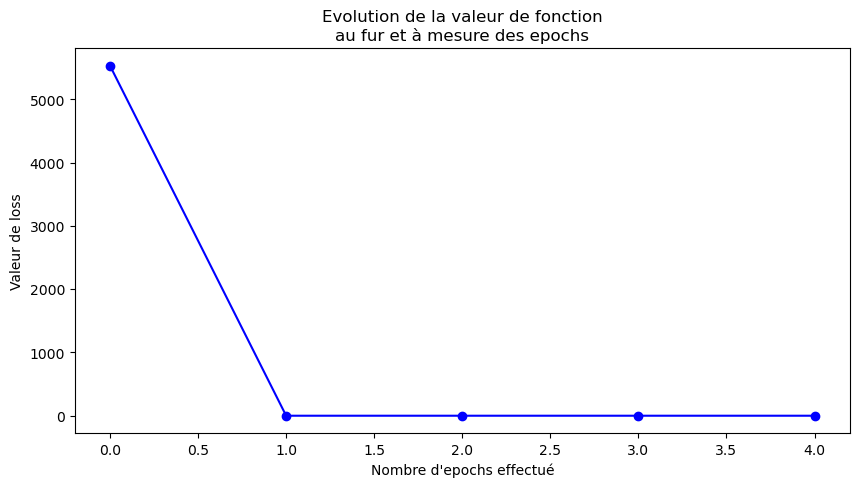

In [283]:
# On doit donc re-entraîner notre modèle sur les données d'entraînement qu'on vient d'extraire

#On réinitialise
embedding_model_face = create_model()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#On produit les triplets à partir de notre train, et on entraîne : c'est pour cela que nous n'avons pas redimensionné les valeurs de train plus haut (on le fait ici)
triplets = create_triplets(data_train)
train(triplets, embedding_model_face, epochs=5)

La convergence se fait très rapidement : le modèle apprend très vite. C'est probablement car les triplets sont trop "faciles" (la différence entre cible pos et cible neg est trop évidente).

In [284]:
#On veut maintenant une fonction qui retourne des pairs d'images

def create_pairs(data):

    labels = []

    #Nombres de correspondances positives et négatives égaux pour avoir une évaluation équilibrée (on prévoit juste le cas où la longueur de data est impair)
    nb_pos = len(data)//2
    nb_neg = int(len(data)/2) if len(data)%2==0 else len(data)//2 - 1

    pairs_pos = []
    #On s'occupe d'abord des positifs
    #Puis on boucle et on prend deux images avec le même visage : 
    for _ in range(nb_pos):
        #On choisit une personne
        k_commun = random.choice(list(data.keys()))
        # Choisir 2 indices au hasard parmi les images de la personne
        indices = random.sample(range(len(data[k_commun])), 2)
        pair = (data[k_commun][indices[0]], data[k_commun][indices[1]])

        #On fait notre tuple
        pairs_pos.append(pair)

        #On ajoute le label qui correspond
        labels.append(1)

    pairs_neg = []
    #Puis des négatifs
    for im in range(nb_neg):
        #On choisit deux personnes différentes au hasard
        k_neg_2 = random.sample(list(data.keys()), 2)

        #On extrait une de leur image chacun

        #Pour chaque, on prend l'index d'une de leur image
        idx0 = random.randint(0, len(data[k_neg_2[0]]) - 1)
        idx1 = random.randint(0, len(data[k_neg_2[1]]) - 1)

        #On utilise les index pour extraire ces images
        pairs_neg.append((data[k_neg_2[0]][idx0], data[k_neg_2[1]][idx1]))

        #On ajoute le label qui correspond
        labels.append(0)

    return pairs_pos + pairs_neg, labels

pairs_test, labels_test = create_pairs(data_test)

#On regarde à quoi ça ressemble
pairs_test[0], labels_test[0]

((<tf.Tensor: shape=(128, 128, 3), dtype=float32, numpy=
  array([[[0.8247877 , 0.7620426 , 0.6208661 ],
          [0.816857  , 0.7580334 , 0.6050922 ],
          [0.8117647 , 0.7575782 , 0.6024907 ],
          ...,
          [0.6424848 , 0.600939  , 0.42892158],
          [0.65208334, 0.6167892 , 0.4518995 ],
          [0.65073746, 0.6173998 , 0.45563725]],
  
         [[0.80389094, 0.748989  , 0.60389096],
          [0.8016544 , 0.74675244, 0.5938113 ],
          [0.80557597, 0.7545956 , 0.5898897 ],
          ...,
          [0.5362132 , 0.5053649 , 0.3499404 ],
          [0.5409895 , 0.511539  , 0.36365297],
          [0.5348216 , 0.5103312 , 0.3612745 ]],
  
         [[0.73087156, 0.6759696 , 0.53087157],
          [0.724663  , 0.67760414, 0.5207414 ],
          [0.724663  , 0.67760414, 0.5147514 ],
          ...,
          [0.35820335, 0.3356005 , 0.20042892],
          [0.35624832, 0.33698085, 0.20827205],
          [0.35162377, 0.33443627, 0.2046875 ]],
  
         ...,
  
     

In [285]:
#Maintenant, on veut une fonction qui calcul la distance entre deux visages (à partir de deux images)
def compute_distances(pairs, model):
    distances = []
    for (img1, img2) in pairs:
        # On ajoute la dimension batch pour que ce soit compatible avec le modèle
        emb1 = model(tf.expand_dims(img1, axis = 0))
        emb2 = model(tf.expand_dims(img2, axis = 0))
        
        # On calcul la distance L2 : la fonction tf.norm le fait automatiquement
        dist = tf.norm(emb1 - emb2).numpy()
        distances.append(dist)
    return distances

In [286]:
#On peut donc calculer le FAR et le FRR

def compute_far_frr(distances, labels, threshold):
    far_count = 0
    frr_count = 0

    #On enregistre le nombre de positifs (mêmes visages) et négatifs (visages différents)
    nb_pos = labels.count(1)
    nb_neg = labels.count(0)
    
    for dist, label in zip(distances, labels):

        #Dans le cas où la distance est moins élevée que le seuil, on considère que ce sont les mêmes visages. Or si le label==0, ce n'est pas le cas : faux positif 
        if label == 0 and dist < threshold:
            far_count += 1  # fausse acceptation

        #Pareil mais dans l'autre sens
        if label == 1 and dist >= threshold:
            frr_count += 1  # faux rejet
    
    #On calcul les taux
    FAR = far_count / nb_neg
    FRR = frr_count / nb_pos

    return FAR, FRR

In [287]:
#On calcule les distances de toutes nos paires
distances = compute_distances(pairs_test, embedding_model_face)

#On définit différents seuils
seuils = np.linspace(0, max(distances), 100)
fars, frrs = [], []

#On calcul pour chaque seuil le FAR et le FRR, pour pouvoir ensuite afficher la courbe ROC
for t in seuils:
    FAR, FRR = compute_far_frr(distances, labels_test, t)
    fars.append(FAR)
    frrs.append(FRR)

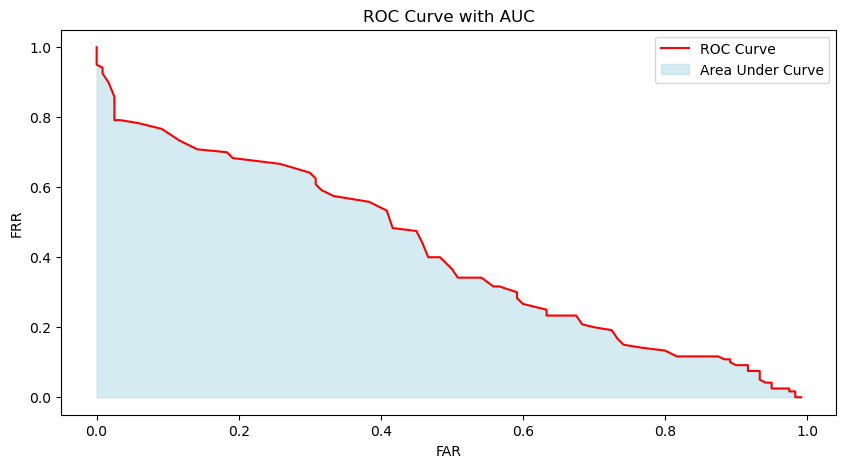

In [288]:
#On peut passer à la partie graphique
plt.figure(figsize=(10,5))
plt.plot(fars, frrs, color="red", label="ROC Curve")
plt.title("ROC Curve with AUC")
plt.xlabel("FAR")
plt.ylabel("FRR")
plt.fill_between(fars, frrs, color= "lightblue", alpha = 0.5, label="Area Under Curve")
plt.legend()
plt.show()

In [289]:
#On calcul l'auc avec la fonction numpy trapz : une valeur proche de 0.5 indique que notre méthode se rapproche plus de l'aléatoire, et idéalement on devrait avoir 0
auc = np.trapz(frrs, fars)
print(f"AUC : {auc:.4f}")

AUC : 0.4094


On voit que le résultat pour ce modèle n'est pas très bon ; on est pas totalement à 0.5 mais on s'en rapproche (alors qu'idéalement on se rapprocherait de 0).

## Implémentation du second modèle : ResNet

On va utiliser le modèle ResNet car on peut réutiliser nos fonctions précédentes (les triplets, la fonction train etc. sont compatibles avec le modèle). Il nou faudra juste refaire le modèle.

La différence entre FaceNet et ResNet est que ResNet permet un entraînement beaucoup plus stable. En effet, il se base sur la différence entre l'entrée et la sortie idéale, ce qui évite que les premières couches de neurones soient délaissées dans l'apprentissage quand le gradient diminue.

In [290]:
#On implémente directement le modèle : on commence par les blocks résiduels
#Ces blocks permettent de sauter des neurones parmis les couches traversées : cela permet à l'entrée d'être directement ajoutée à la sortie, sans passer par certaines couches.

def residual_block(x, filters):
    # Chemin principal
    shortcut = x

    #On notera le paramètre padding = 'same' qui permet d'avoir une sortie de la même taille que l'entrée, afin de pouvoir, au final, les ajouter ensemble 
    x = tf.keras.layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(filters, (3,3), padding='same')(x)

    # Si les dimensions ne correspondent pas, on adapte le shortcut
    if shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, (1,1), padding='same')(shortcut)
    
    # Raccourci : additionne l'entrée à la sortie
    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

In [291]:
#Quand on a les blocs résiduels, on peut passer à l'implémentation du resnet

def create_resnet():
    inputs = tf.keras.Input(shape=(128, 128, 3))
    
    # Première couche classique
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D()(x)
    
    # Blocs résiduels
    x = residual_block(x, 32)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = residual_block(x, 64)  # augmente les filtres
    
    # Embedding final
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128)(x)
    
    #On notera qu'on n'utilise plus Sequential car notre modèle n'est plus linéaire
    return tf.keras.Model(inputs, outputs=x)

create_resnet().summary()

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_146 (Conv2D) │ (None, 128, 128,  │        896 │ input_layer_35[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_91    │ (None, 64, 64,    │          0 │ conv2d_146[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_147 (Conv2D) │ (None, 64, 64,    │      9,248 │ max_pooling2d_91… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_148 (Conv2D) │ (None, 64, 64,    │      9,248 │ conv2d_147[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 64, 64,    │          0 │ conv2d_148[0][0], │
│                     │ 32)               │            │ max_pooling2d_91… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 64, 64,    │          0 │ add_28[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_92    │ (None, 32, 32,    │          0 │ activation_27[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_149 (Conv2D) │ (None, 32, 32,    │     18,496 │ max_pooling2d_92… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_150 (Conv2D) │ (None, 32, 32,    │     36,928 │ conv2d_149[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_151 (Conv2D) │ (None, 32, 32,    │      2,112 │ max_pooling2d_92… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 32, 32,    │          0 │ conv2d_150[0][0], │
│                     │ 64)               │            │ conv2d_151[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 32, 32,    │          0 │ add_29[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_28[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 128)       │      8,320 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 85,248 (333.00 KB)

 Trainable params: 85,248 (333.00 KB)

 Non-trainable params: 0 (0.00 B)

On peut observer toutes les couches qu'on a définit.

Epoch 1, Loss moyenne: 0.6437
Epoch 2, Loss moyenne: 0.1529
Epoch 3, Loss moyenne: 0.0000
Epoch 4, Loss moyenne: 0.0000
Epoch 5, Loss moyenne: 0.0000


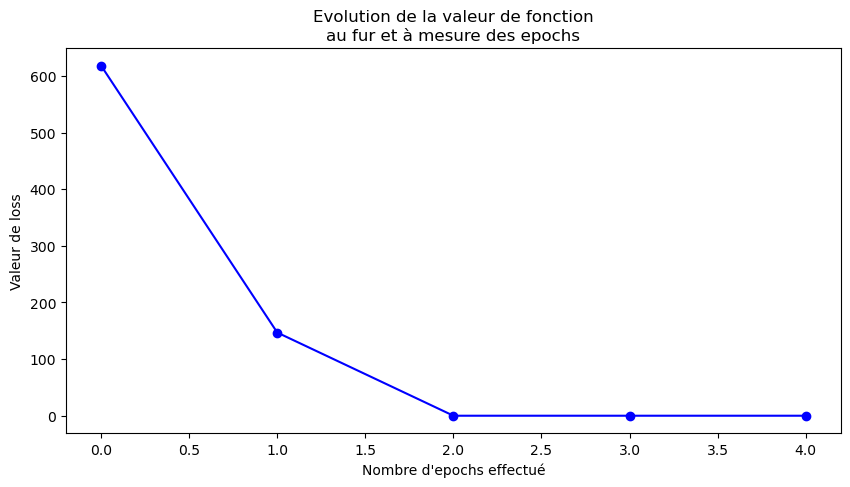

In [292]:
# Le workflow est identique à FaceNet, on a juste à recopier
embedding_model_res = create_resnet()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
triplets = create_triplets(data_train)
train(triplets, embedding_model_res, epochs=5)

## Evaluation ResNet

In [293]:
#Mêmes étapes qu'avec FaceNet

#On calcule les distances de toutes nos paires : on réutilise le même pairs_test pour comparer sur la même base que FaceNet
distances_res = compute_distances(pairs_test, embedding_model_res)

#On définit différents seuils
seuils = np.linspace(0, max(distances_res), 100)
fars_res, frrs_res = [], []

#On calcul pour chaque seuil le FAR et le FRR, pour pouvoir ensuite afficher la courbe ROC
for t in seuils:
    #On utilise donc les distances de ResNet, les labels eux ne changent pas
    FAR_res, FRR_res = compute_far_frr(distances_res, labels_test, t)
    fars_res.append(FAR_res)
    frrs_res.append(FRR_res)


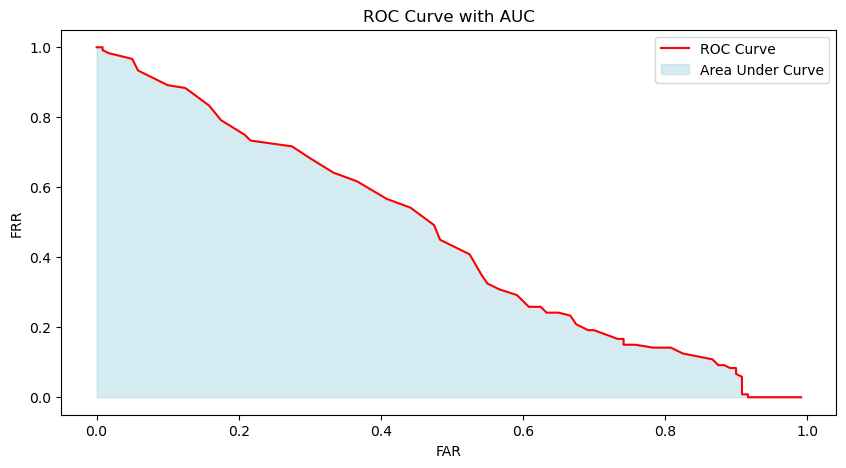

In [294]:
#On peut passer à la partie graphique
plt.figure(figsize=(10,5))
plt.plot(fars_res, frrs_res, color="red", label="ROC Curve")
plt.title("ROC Curve with AUC")
plt.xlabel("FAR")
plt.ylabel("FRR")
plt.fill_between(fars_res, frrs_res, color= "lightblue", alpha = 0.5, label="Area Under Curve")
plt.legend()
plt.show()

In [295]:
#On calcul l'auc avec la fonction numpy trapz : une valeur proche de 0.5 indique que notre méthode se rapproche plus de l'aléatoire, et idéalement on devrait avoir 0
auc_res = np.trapz(frrs_res, fars_res)
print(f"AUC : {auc_res:.4f}")

AUC : 0.4516


In [296]:
#Afin de réaliser notre application, on a besoin de sauvegarder nos modèles 
embedding_model_face.save('facenet_model.keras')
embedding_model_res.save('resnet_model.keras')

## Application GUI

In [297]:
import ipywidgets as widgets

In [298]:
#On a d'abord besoin d'une fonction qui traite les images qui sont uploadées dans l'application : les mettre au bon format, à la bonne dimension
#De cette manière, on pourra utiliser nos modèles dessus

def preprocess_image(image_bytes):
    # On décode les bytes en tensor
    img = tf.image.decode_image(image_bytes, channels=3)

    # On redimensionne et normalise
    img = tf.image.resize(img, (128, 128))
    img = img / 255.0
    return img

#On a également besoin d'une fonction qui calcule la distance entre deux images seulement. La nôtre le faisait sur une liste de pairs d'images
def get_distance(img1, img2, model):
    emb1 = model(tf.expand_dims(img1, axis=0))
    emb2 = model(tf.expand_dims(img2, axis=0))
    return tf.norm(emb1 - emb2).numpy()

In [299]:
from IPython.display import display
from PIL import Image
import io

#C'est le squelette de notre application 

# Deux boutons d'upload
upload1 = widgets.FileUpload(accept='image/*', multiple=False, description='Image 1')
upload2 = widgets.FileUpload(accept='image/*', multiple=False, description='Image 2')

# Bouton comparer
bouton = widgets.Button(description='Comparer', button_style='primary')

# Zone d'affichage des résultats
output = widgets.Output()

def on_click(b):
    with output:
        output.clear_output()
        
        # Récupère les bytes des images uploadées
        bytes1 = list(upload1.value.values())[0]['content']
        bytes2 = list(upload2.value.values())[0]['content']
        
        # Prétraite les images
        img1 = preprocess_image(bytes1)
        img2 = preprocess_image(bytes2)
        
        # On calcul les distances pour chaque modèle
        dist_face = get_distance(img1, img2, embedding_model_face)
        dist_res = get_distance(img1, img2, embedding_model_res)

        #On attriblue la prédiction de chaque modèle
        pred_face = "Même visage ✅" if dist_face <=0.5 else "Pas le même visage ❌"
        pred_res = "Même visage ✅" if dist_res <=0.5 else "Pas le même visage ❌"

        #On affiche les images uploadés
        fig, ax = plt.subplots(1, 2, figsize=(6, 3))
        ax[0].imshow(img1.numpy())
        ax[0].axis('off')
        ax[1].imshow(img2.numpy())
        ax[1].axis('off')
        plt.show()

        # On affiche la prédiction de chaque modèle, en rappelant leur auc (pour avoir une idée de la fiabilité)
        print(f"Prédiction de FaceNet (score AUC:{auc:.4f}) : ", pred_face)
        print(f"Prédiction de ResNet (score AUC:{auc_res:.4f}) : ", pred_res)


display(upload1, upload2, bouton, output)
bouton.on_click(on_click)

FileUpload(value={}, accept='image/*', description='Image 1')

FileUpload(value={}, accept='image/*', description='Image 2')

Button(button_style='primary', description='Comparer', style=ButtonStyle())

Output()